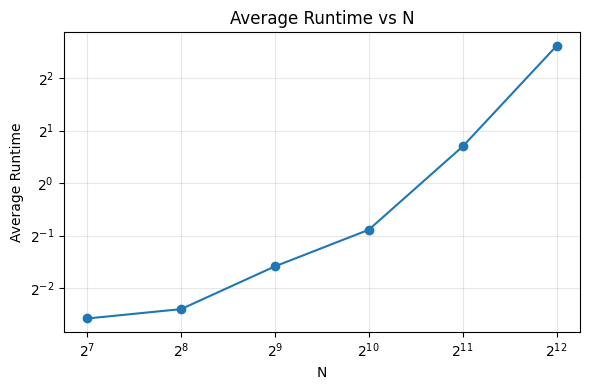

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data (assumes columns: N, runtime)
data_serial = pd.read_csv("nbody_serial_runtimes.txt", delimiter=",", header=None)

# Keep first two columns and name them
data_serial = data_serial.iloc[:, [0, 2]]
data_serial.columns = ["N", "runtime"]

# Convert columns to numeric (invalid values become NaN)
data_serial["N"] = pd.to_numeric(data_serial["N"], errors="coerce")
data_serial["runtime"] = pd.to_numeric(data_serial["runtime"], errors="coerce")

# Compute average runtime for each N
avg_runtimes = data_serial.groupby("N", as_index=False)["runtime"].mean().sort_values("N")

# Plot average runtime vs N
plt.figure(figsize=(6, 4))
plt.plot(avg_runtimes["N"], avg_runtimes["runtime"], marker="o")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("N")
plt.ylabel("Average Runtime")
plt.title("Average Runtime vs N")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

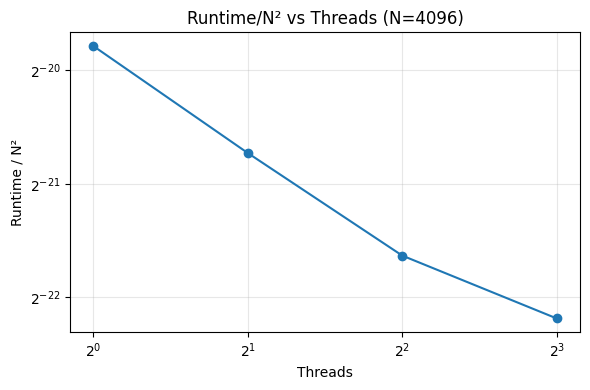

In [2]:
# Load OMP data
data_omp = pd.read_csv("nbody_omp_runtimes.txt", delimiter=",", header=None)

# Keep first three columns and name them
data_omp = data_omp.iloc[:, [0, 1, 2]]
data_omp.columns = ["N", "threads", "runtime"]

# Convert columns to numeric
data_omp["N"] = pd.to_numeric(data_omp["N"], errors="coerce")
data_omp["threads"] = pd.to_numeric(data_omp["threads"], errors="coerce")
data_omp["runtime"] = pd.to_numeric(data_omp["runtime"], errors="coerce")

# Filter for selected_N and compute runtime/N^2
selected_N = data_omp["N"].max()  # Use the largest N available in the OMP data
runtimes_for_N_omp = data_omp[data_omp["N"] == selected_N].copy()
runtimes_for_N_omp["runtime_over_N2"] = runtimes_for_N_omp["runtime"] / (selected_N ** 2)

# Plot runtime/N^2 vs threads
plt.figure(figsize=(6, 4))
plt.plot(runtimes_for_N_omp["threads"], runtimes_for_N_omp["runtime_over_N2"], marker="o")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Threads")
plt.ylabel("Runtime / N²")
plt.title(f"Runtime/N² vs Threads (N={int(selected_N)})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

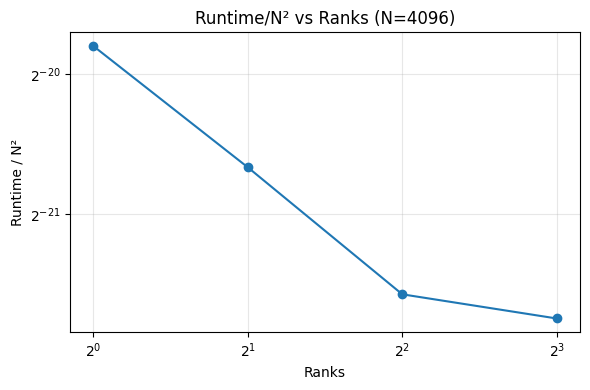

In [3]:
# Load MPI data
data_mpi = pd.read_csv("nbody_mpi_runtimes.txt", delimiter=",", header=None)

# Keep first three columns and name them
data_mpi = data_mpi.iloc[:, [0, 1, 2]]
data_mpi.columns = ["N", "ranks", "runtime"]

# Convert columns to numeric
data_mpi["N"] = pd.to_numeric(data_mpi["N"], errors="coerce")
data_mpi["ranks"] = pd.to_numeric(data_mpi["ranks"], errors="coerce")
data_mpi["runtime"] = pd.to_numeric(data_mpi["runtime"], errors="coerce")

# Filter for selected_N and compute runtime/N^2
selected_N = data_mpi["N"].max()  # Use the largest N available in the MPI data
runtimes_for_N_mpi = data_mpi[data_mpi["N"] == selected_N].copy()
runtimes_for_N_mpi["runtime_over_N2"] = runtimes_for_N_mpi["runtime"] / (selected_N ** 2)

# Plot runtime/N^2 vs threads
plt.figure(figsize=(6, 4))
plt.plot(runtimes_for_N_mpi["ranks"], runtimes_for_N_mpi["runtime_over_N2"], marker="o")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Ranks")
plt.ylabel("Runtime / N²")
plt.title(f"Runtime/N² vs Ranks (N={int(selected_N)})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

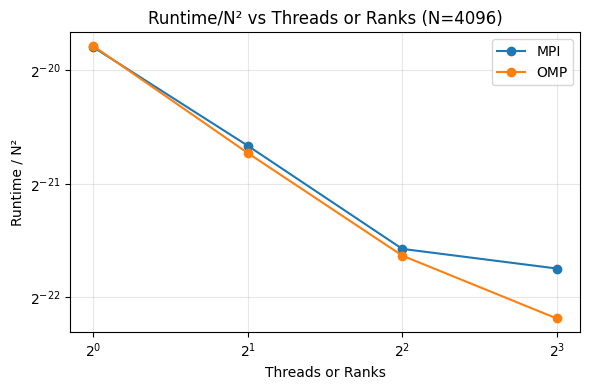

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(runtimes_for_N_mpi["ranks"], runtimes_for_N_mpi["runtime_over_N2"], marker="o", label="MPI")
plt.plot(runtimes_for_N_omp["threads"], runtimes_for_N_omp["runtime_over_N2"], marker="o", label="OMP")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Threads or Ranks")
plt.ylabel("Runtime / N²")
plt.title(f"Runtime/N² vs Threads or Ranks (N={int(selected_N)})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()